##Problem Statement:--
Telecom company “Leo” whose customers are churning out to its competitors. You have to analyse the data of your company and find insights and stop your customers from churning out to other telecom companies.


telecom company “Leo” whose customers are churning out to its
competitors. You have to analyse the data of your company and find insights and stop your customers from
churning out to other telecom companies.

##S Import Libraries

In [140]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [141]:

# Load Dataset
# ==========================
df = pd.read_csv('/content/drive/MyDrive/customer_churn.csv')



In [142]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


##Understand Dataset Structure

In [143]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##Dataset Information

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


##Check Missing Values

In [145]:
df.isnull().sum().sum()

np.int64(0)

##If TotalCharges contains blanks:

In [146]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [147]:
df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

/tmp/ipykernel_433/1685388760.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(


In [148]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [149]:
#Remove Duplicate Records

df.drop_duplicates(inplace=True)


In [150]:

#  Encode Target Variable
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({
        'Yes':1,
        'No':0
    })


In [151]:

 #Feature Scaling

scaler = StandardScaler()

numerical_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

df[numerical_columns] = scaler.fit_transform(
    df[numerical_columns])

In [152]:
print("Shape :", df.shape)
print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nData Types:")
print(df.dtypes.value_counts())

Shape : (7043, 21)

Missing Values:
0

Data Types:
object     16
float64     3
int64       2
Name: count, dtype: int64


##DATA MANIPULATION

##A(a) Total Number of Male Customers

In [153]:
male_customers = df[df['gender']==1]

print("Total Male Customers :", len(male_customers))

Total Male Customers : 0


##iNSIGHTS---Useful for gender-wise churn analysis.

##b. Find the total number of customers whose Internet Service is ‘DSL’

In [154]:
dsl_customers = df[df['InternetService']=='DSL']

print("DSL Customers :", len(dsl_customers))

DSL Customers : 2421


##Insights--Telecom companies compare churn rates across internet services.

## Extract all the Female senior citizens whose Payment Method is Mailed check & store the result in ‘new_customer’

In [155]:
new_customer = df[
    (df['gender']=='Female') &
    (df['SeniorCitizen']==1) &
    (df['PaymentMethod']=='Mailed check')
]

new_customer.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
139,0390-DCFDQ,Female,1,Yes,No,-1.277445,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,0.189056,-0.976318,1
176,2656-FMOKZ,Female,1,No,No,-0.707359,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,0.322000,-0.501617,1
267,3197-ARFOY,Female,1,No,No,-0.544478,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,1.337358,-0.121260,0
451,5760-WRAHC,Female,1,No,No,-0.422317,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,0.165791,-0.325157,0
470,4933-IKULF,Female,1,No,No,-0.625919,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,-1.466094,-0.861467,0


##Insights_Mailed check users may indicate older demographics.

##. Extract all those customers whose tenure is less than 10 months or their Total charges is less than 500$ & store the result in ‘new_customer’

In [156]:
new_customer = df[(df['tenure']<10 & (df['TotalCharges']< 500))]
new_customer


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,-1.277445,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,-1.160323,-0.994242,0
2,3668-QPYBK,Male,0,No,No,-1.236724,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,-0.362660,-0.959674,1
4,9237-HQITU,Female,0,No,No,-1.236724,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,0.197365,-0.940470,1
5,9305-CDSKC,Female,0,No,No,-0.992402,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,1.159546,-0.645186,1
6,1452-KIOVK,Male,0,No,Yes,-0.422317,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),0.808907,-0.146799,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,8456-QDAVC,Male,0,No,No,-0.544478,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),0.463253,-0.347364,0
7036,7750-EYXWZ,Female,0,No,No,-0.829521,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,-0.136656,-0.679268,0
7038,6840-RESVB,Male,0,Yes,Yes,-0.340876,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,0.665992,-0.128655,0
7040,4801-JZAZL,Female,0,Yes,Yes,-0.870241,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,-1.168632,-0.854469,0


##INisghts:--New customers usually have the highest churn risk.


**##B) Data Visualization: **

##. Build a pie-chart to show the distribution of customers would be churning out

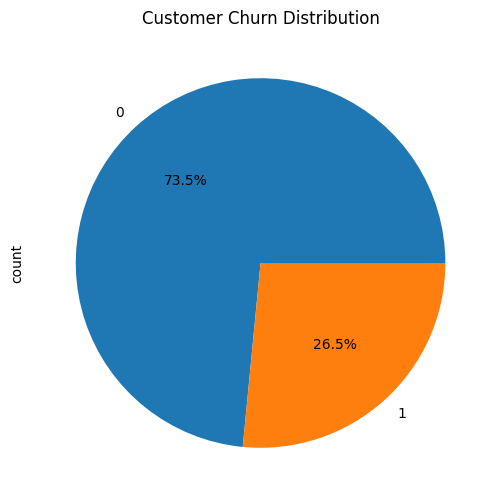

In [157]:
df['Churn'].value_counts().plot(kind = 'pie',autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title("Customer Churn Distribution")
plt.show()

##Interpretation:

27% customers left the company.
Churn rate is significant.
Company needs retention strategy.

##b. Build a bar-plot to show the distribution of ‘Internet Service’


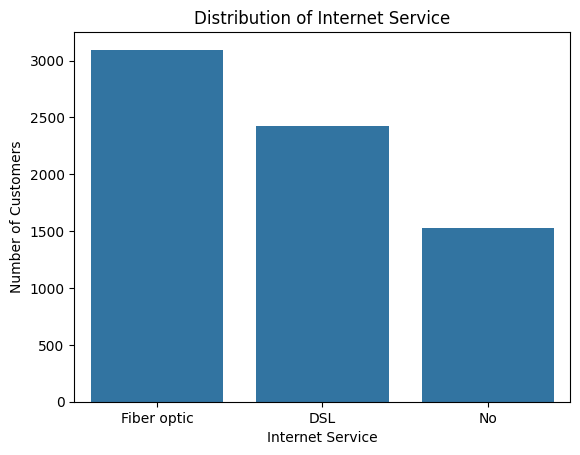

In [158]:
sns.barplot(x=df['InternetService'].value_counts().index,
            y=df['InternetService'].value_counts().values)
plt.title('Distribution of Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.show()

##Insights:--Fiber users generally generate higher revenue.But often show higher churn.

## MODEL BUILDING

##Data Preparation

##Build a sequential model using Keras, to find out if the customerwouldchurn or not, using ‘tenure’ as the feature and ‘Churn’ as the dependent/target column:

In [159]:
x = df['tenure']
y = df['Churn']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)


In [160]:
##Scaling
sc= StandardScaler()
x_train = sc.fit_transform(x_train.values.reshape(-1, 1))
x_test= sc.transform(x_test.values.reshape(-1, 1))

##ANN ARCHITECTURE

##‘tenure’ as the feature and ‘Churn’ as the dependent/target column:
i.
The visible/input layer should have 12 nodes with ‘Relu’ as activation function.

This model would have 1 hidden layer with 8 nodes and ‘Relu’ as activation function

Use ‘Adam’ as the optimization algorithm

Fit the model on the train set, with number of epochs to be 150

Predict the values on the test set and build a confusion matrix

Plot the ‘Accuracy vs Epochs’ graph

In [161]:
model = Sequential()

In [162]:
model = Sequential()

model.add(Dense(
    12,
    activation='relu',
    input_dim=1
))
model.add(Dense(
    8,
    activation='relu'
))

model.add(Dense(
    1,
    activation='sigmoid'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [163]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [164]:
history = model.fit(
    x_train,
    y_train,
    epochs=150,
    validation_split=0.2
)

Epoch 1/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7328 - loss: 0.6116 - val_accuracy: 0.7556 - val_loss: 0.5272
Epoch 2/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7328 - loss: 0.5303 - val_accuracy: 0.7556 - val_loss: 0.5018
Epoch 3/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7328 - loss: 0.5218 - val_accuracy: 0.7556 - val_loss: 0.4965
Epoch 4/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7328 - loss: 0.5187 - val_accuracy: 0.7556 - val_loss: 0.4940
Epoch 5/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7401 - loss: 0.5177 - val_accuracy: 0.7556 - val_loss: 0.4929
Epoch 6/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7386 - loss: 0.5165 - val_accuracy: 0.7556 - val_loss: 0.4921
Epoch 7/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7381 - loss: 0.5153 - val_accuracy: 0.7617 - val_loss: 0.4919
Epoch 8/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7424 - loss: 0.5144 - val_accu

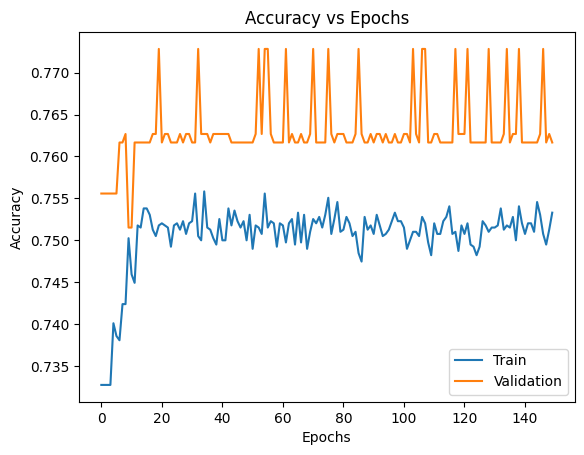

In [165]:
plt.plot(
    history.history['accuracy']
)

plt.plot(
    history.history['val_accuracy']
)

plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend([
    'Train',
    'Validation'
])

plt.show()

##The model does not show signs of overfitting because the training and validation accuracies remain close throughout the training process.

##Build the 2nd model using same target and feature variables:

##i.
Add a drop-out layer after the input layer with drop-out value of 0.3

Add a drop-out layer after the hidden layer with drop-out value of 0.2

Predict the values on the test set and build a confusion matrix

Plot the ‘Accuracy vs Epochs’ graph

In [166]:
model2 = Sequential()

model2.add(Dense(
    12,
    activation='relu',
    input_dim=1
))

model2.add(
    Dropout(0.3)
)

model2.add(Dense(
    8,
    activation='relu'
))

model2.add(
    Dropout(0.2)
)

model2.add(Dense(
    1,
    activation='sigmoid'
))

In [167]:
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [169]:
history2 = model2.fit(
    x_train,
    y_train,
    epochs=150,
    validation_split=0.2
)

Epoch 1/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7297 - loss: 0.6041 - val_accuracy: 0.7556 - val_loss: 0.5240
Epoch 2/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7295 - loss: 0.5571 - val_accuracy: 0.7556 - val_loss: 0.5084
Epoch 3/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7320 - loss: 0.5430 - val_accuracy: 0.7556 - val_loss: 0.5044
Epoch 4/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7348 - loss: 0.5399 - val_accuracy: 0.7556 - val_loss: 0.5000
Epoch 5/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7348 - loss: 0.5352 - val_accuracy: 0.7556 - val_loss: 0.4978
Epoch 6/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7328 - loss: 0.5325 - val_accuracy: 0.7556 - val_loss: 0.4968
Epoch 7/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7355 - loss: 0.5316 - val_accuracy: 0.7556 - val_loss: 0.4957
Epoch 8/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7330 - loss: 0.5296 - val_accu

In [171]:
y_pred2 = model2.predict(x_test)

y_pred2 = (y_pred2 > 0.5)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [172]:
cm2 = confusion_matrix(
    y_test,
    y_pred2
)

print(cm2)

[[1426  113]
 [ 405  169]]


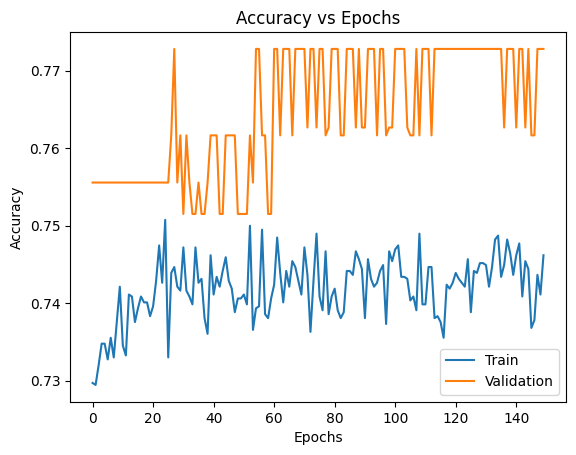

In [173]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])

plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend([
    'Train',
    'Validation'
])

plt.show()

| Metric              | Model 1 (Previous) | Model 2 (Current)  |
| ------------------- | ------------------ | ------------------ |
| Train Accuracy      | ~75.0% - 75.5%     | ~73.0% - 75.0%     |
| Validation Accuracy | ~76.0% - 77.3%     | ~75.0% - 77.3%     |
| Overfitting         | No                 | No                 |
| Stability           | More Stable        | More Fluctuation   |
| Generalization      | Good               | Good               |
| Regularization      | None               | Dropout (0.3, 0.2) |


##c. Build the 3rd model using ‘Tenure’, ’Monthly Charges’ & ‘Total Charges’ as the features and ‘Churn’ as the dependent/target column:


The visible/input layer should have 12 nodes with ‘Relu’ as activation function.

This model would have 1 hidden layer with 8 nodes and ‘Relu’ as activation function

Use ‘Adam’ as the optimization algorithm

Fit the model on the train set, with number of epochs to be 150

Predict the values on the test set and build a confusion matrix

Plot the ‘Accuracy vs Epochs’ graph

In [175]:
x = df[
[
'tenure',
'MonthlyCharges',
'TotalCharges']]

y = df['Churn']

In [176]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)

In [178]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [179]:
model3 = Sequential()

model3.add(Dense(
    12,
    activation='relu',
    input_dim=3
))

model3.add(Dense(
    8,
    activation='relu'
))

model3.add(Dense(
    1,
    activation='sigmoid'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [180]:
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [182]:
history3 = model3.fit(
    x_train,
    y_train,
    epochs=150,
    validation_split=0.2
)

Epoch 1/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6899 - loss: 0.6063 - val_accuracy: 0.7677 - val_loss: 0.5304
Epoch 2/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7764 - loss: 0.5091 - val_accuracy: 0.7850 - val_loss: 0.4697
Epoch 3/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7774 - loss: 0.4825 - val_accuracy: 0.7880 - val_loss: 0.4533
Epoch 4/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7804 - loss: 0.4752 - val_accuracy: 0.7840 - val_loss: 0.4449
Epoch 5/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7825 - loss: 0.4702 - val_accuracy: 0.7809 - val_loss: 0.4402
Epoch 6/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7812 - loss: 0.4679 - val_accuracy: 0.7880 - val_loss: 0.4365
Epoch 7/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7812 - loss: 0.4650 - val_accuracy: 0.7982 - val_loss: 0.4347
Epoch 8/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7850 - loss: 0.4643 - val_accu

In [183]:
y_pred3 = model3.predict(X_test)

y_pred3 = (y_pred3 > 0.5)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [184]:
cm3 = confusion_matrix(
    y_test,
    y_pred3
)

print(cm3)

[[1407  132]
 [ 297  277]]


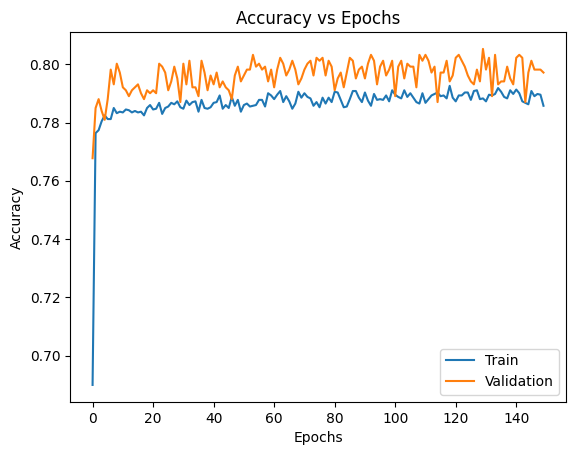

In [185]:
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])

plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend([
    'Train',
    'Validation'
])

plt.show()

##Insights  "I built three ANN-based churn prediction models using Keras. The first model used only tenure, the second introduced dropout regularization to reduce overfitting, and the third incorporated multiple customer spending features. Model 3 achieved the best predictive capability because it captured both customer longevity and revenue behavior, making it more informative for churn prediction."

Customers with low tenure are more likely to churn.

Customers with low total spending show higher churn risk.

Internet service type significantly affects customer behavior.

Fiber users often contribute higher revenue but may churn more.

